In [1]:
import pandas as pd
df = pd.read_csv('df_ml_LS.csv')

In [2]:
df.columns

Index(['target', 'ddd', 'Regiao', 'n_tentativas_anteriores',
       'horas_desde_primeiro_contato', 'n_voicemail_reached_anteriores',
       'n_dial_no_answer_anteriores', 'n_inactivity_anteriores',
       'N_invalid_destination_anteriores', 'N_user_hangup_anteriores',
       'N_user_declined_anteriores',
       'N_telephony_provider_permission_denied_anteriores',
       'N_dial_busy_anteriores', 'N_telephony_provider_unavailable_anteriores',
       'N_agent_hangup_anteriores', 'N_error_asr_anteriores',
       'N_error_retell_anteriores', 'N_dial_failed_anteriores',
       'N_max_duration_reached_anteriores', 'N_ivr_reached_anteriores',
       'ultima_disconnection_reason'],
      dtype='object')

In [3]:
df.head()

,target,ddd,Regiao,n_tentativas_anteriores,horas_desde_primeiro_contato,n_voicemail_reached_anteriores,n_dial_no_answer_anteriores,n_inactivity_anteriores,N_invalid_destination_anteriores,N_user_hangup_anteriores,...,N_telephony_provider_permission_denied_anteriores,N_dial_busy_anteriores,N_telephony_provider_unavailable_anteriores,N_agent_hangup_anteriores,N_error_asr_anteriores,N_error_retell_anteriores,N_dial_failed_anteriores,N_max_duration_reached_anteriores,N_ivr_reached_anteriores,ultima_disconnection_reason
0,0,11,SP,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,primeiro_contato
1,0,11,SP,1.0,0.106000,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,invalid_destination
2,0,11,SP,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,primeiro_contato
3,0,11,SP,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,primeiro_contato
4,0,11,SP,1.0,0.086529,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,invalid_destination


In [4]:
len(df)

45676

## Isolamento de targert e features


In [5]:
y = df['target']
X = df.drop('target', axis=1)

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

print('\nFirst 5 rows of X:')
display(X.head())

print('\nFirst 5 rows of y:')
display(y.head())

Shape of X: (45676, 20)
Shape of y: (45676,)

First 5 rows of X:


,ddd,Regiao,n_tentativas_anteriores,horas_desde_primeiro_contato,n_voicemail_reached_anteriores,n_dial_no_answer_anteriores,n_inactivity_anteriores,N_invalid_destination_anteriores,N_user_hangup_anteriores,N_user_declined_anteriores,N_telephony_provider_permission_denied_anteriores,N_dial_busy_anteriores,N_telephony_provider_unavailable_anteriores,N_agent_hangup_anteriores,N_error_asr_anteriores,N_error_retell_anteriores,N_dial_failed_anteriores,N_max_duration_reached_anteriores,N_ivr_reached_anteriores,ultima_disconnection_reason
0,11,SP,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,primeiro_contato
1,11,SP,1.0,0.106000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,invalid_destination
2,11,SP,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,primeiro_contato
3,11,SP,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,primeiro_contato
4,11,SP,1.0,0.086529,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,invalid_destination



First 5 rows of y:


,target
0,0
1,0
2,0
3,0
4,0


In [6]:
columns_to_categorize = [
    'agent_id',
    'Regiao',
    'ultima_disconnection_reason',
    'ddd'
]

for col in columns_to_categorize:
    if col in X.columns:
        # Convert to string first to avoid floating point category index errors in XGBoost
        X[col] = X[col].astype(str).astype('category')
    else:
        print(f"Column '{col}' not found in X and was skipped.")

# Convert specified columns to integer type
columns_to_int = [
    'n_tentativas_anteriores',
    'n_voicemail_reached_anteriores',
    'n_dial_no_answer_anteriores',
    'n_inactivity_anteriores',
    'N_invalid_destination_anteriores',
    'N_user_hangup_anteriores',
    'N_user_declined_anteriores',
    'N_telephony_provider_permission_denied_anteriores',
    'N_dial_busy_anteriores',
    'N_telephony_provider_unavailable_anteriores',
    'N_agent_hangup_anteriores',
    'N_error_asr_anteriores',
    'N_error_retell_anteriores',
    'N_dial_failed_anteriores',
    'N_max_duration_reached_anteriores',
    'N_ivr_reached_anteriores'
]

for col in columns_to_int:
    if col in X.columns:
        X[col] = X[col].astype('int64')
    else:
        print(f"Column '{col}' not found in X and was skipped for integer conversion.")

print("Data types after conversion (ensuring strings for categories and int for others):")
display(X.dtypes)

Column 'agent_id' not found in X and was skipped.
Data types after conversion (ensuring strings for categories and int for others):


,0
ddd,category
Regiao,category
n_tentativas_anteriores,int64
horas_desde_primeiro_contato,float64
n_voicemail_reached_anteriores,int64
n_dial_no_answer_anteriores,int64
n_inactivity_anteriores,int64
N_invalid_destination_anteriores,int64
N_user_hangup_anteriores,int64
N_user_declined_anteriores,int64


In [7]:
from sklearn.model_selection import train_test_split

# Re-split the data since we updated X types to ensure X_train and X_test have the new string categories
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Update references to encoded datasets (which are now just the original DFs with category dtypes)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

print('Shape of X_train:', X_train.shape)
print('Class distribution in y_train:')
print(y_train.value_counts(normalize=True))

Shape of X_train: (36540, 20)
Class distribution in y_train:
target
0    0.965982
1    0.034018
Name: proportion, dtype: float64


### One-Hot Encoding Categorical Features

Before training the XGBoost model, we need to convert categorical features into a numerical format. One-Hot Encoding is a common technique for this, creating new binary columns for each category level.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

# Instead of OneHotEncoder, we ensure the categorical columns remain as 'category' dtypes
# XGBoost with enable_categorical=True will handle them automatically

categorical_cols = X_train.select_dtypes(include='category').columns

def pass_through(x):
    return x

# We use a ColumnTransformer that just passes through the data
# This keeps our workflow consistent if we need to add scalers later
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', FunctionTransformer(pass_through), categorical_cols)
    ],
    remainder='passthrough'
)

# Since we are not encoding into new shapes, we can use the data directly
# but we must ensure the dtypes are preserved for XGBoost
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

print('Shape of X_train:', X_train_encoded.shape)
print('Categorical columns identified:', list(categorical_cols))

Shape of X_train: (36540, 20)
Categorical columns identified: ['ddd', 'Regiao', 'ultima_disconnection_reason']


### Training and Evaluating XGBoost Baseline Model

Now we will train an XGBoost Classifier on the encoded data. Due to the imbalanced target variable, we will calculate `scale_pos_weight` to assign more importance to the minority class (target=1) during training.

In [9]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# Recalculate scale_pos_weight
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

# Initialize XGBoost with Native Categorical Support and fixed category types
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,  # Now enabled
    tree_method='hist'        # Required for categorical
)

# Fit the model
model.fit(X_train_encoded, y_train)

# Predictions
y_pred = model.predict(X_test_encoded)
y_pred_proba = model.predict_proba(X_test_encoded)[:, 1]

# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

Accuracy: 0.9829
Precision: 0.7003
Recall: 0.8714
F1-Score: 0.7765
ROC AUC Score: 0.9821


In [10]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Matriz de Confusão (Valores Absolutos):")
print(f"Verdadeiros Negativos (0): {tn}")
print(f"Falsos Positivos (Erro Tipo I): {fp}")
print(f"Falsos Negativos (Erro Tipo II): {fn}")
print(f"Verdadeiros Positivos (1): {tp}")

print("\nRepresentação em Array:")
print(cm)

Matriz de Confusão (Valores Absolutos):
Verdadeiros Negativos (0): 8709
Falsos Positivos (Erro Tipo I): 116
Falsos Negativos (Erro Tipo II): 40
Verdadeiros Positivos (1): 271

Representação em Array:
[[8709  116]
 [  40  271]]


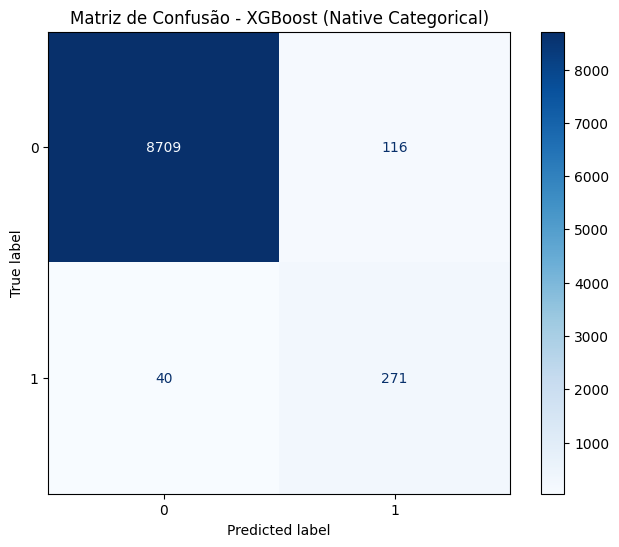

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusão - XGBoost (Native Categorical)')
plt.show()

In [12]:
import json

# Get all parameters from the trained XGBoost model
params = model.get_params()

print("Hiperparâmetros do modelo XGBoost:")
# Displaying as a pretty-printed JSON for better readability
print(json.dumps(params, indent=4, default=str))

Hiperparâmetros do modelo XGBoost:
{
    "objective": "binary:logistic",
    "base_score": null,
    "booster": null,
    "callbacks": null,
    "colsample_bylevel": null,
    "colsample_bynode": null,
    "colsample_bytree": null,
    "device": null,
    "early_stopping_rounds": null,
    "enable_categorical": true,
    "eval_metric": "logloss",
    "feature_types": null,
    "feature_weights": null,
    "gamma": null,
    "grow_policy": null,
    "importance_type": null,
    "interaction_constraints": null,
    "learning_rate": null,
    "max_bin": null,
    "max_cat_threshold": null,
    "max_cat_to_onehot": null,
    "max_delta_step": null,
    "max_depth": null,
    "max_leaves": null,
    "min_child_weight": null,
    "missing": NaN,
    "monotone_constraints": null,
    "multi_strategy": null,
    "n_estimators": null,
    "n_jobs": null,
    "num_parallel_tree": null,
    "random_state": 42,
    "reg_alpha": null,
    "reg_lambda": null,
    "sampling_method": null,
    "scale_

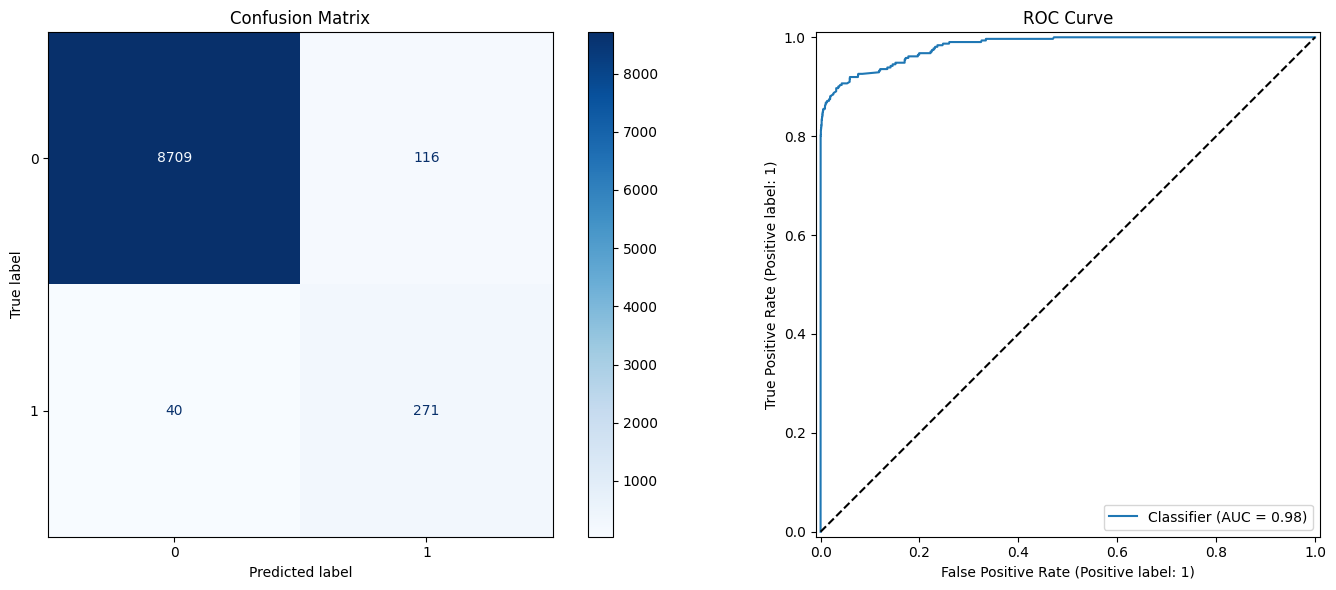

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# Set up the figure with three subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
ax[0].set_title('Confusion Matrix')

# 2. Plot ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=ax[1])
ax[1].set_title('ROC Curve')
ax[1].plot([0, 1], [0, 1], 'k--') # Diagonal line

plt.tight_layout()
plt.show()

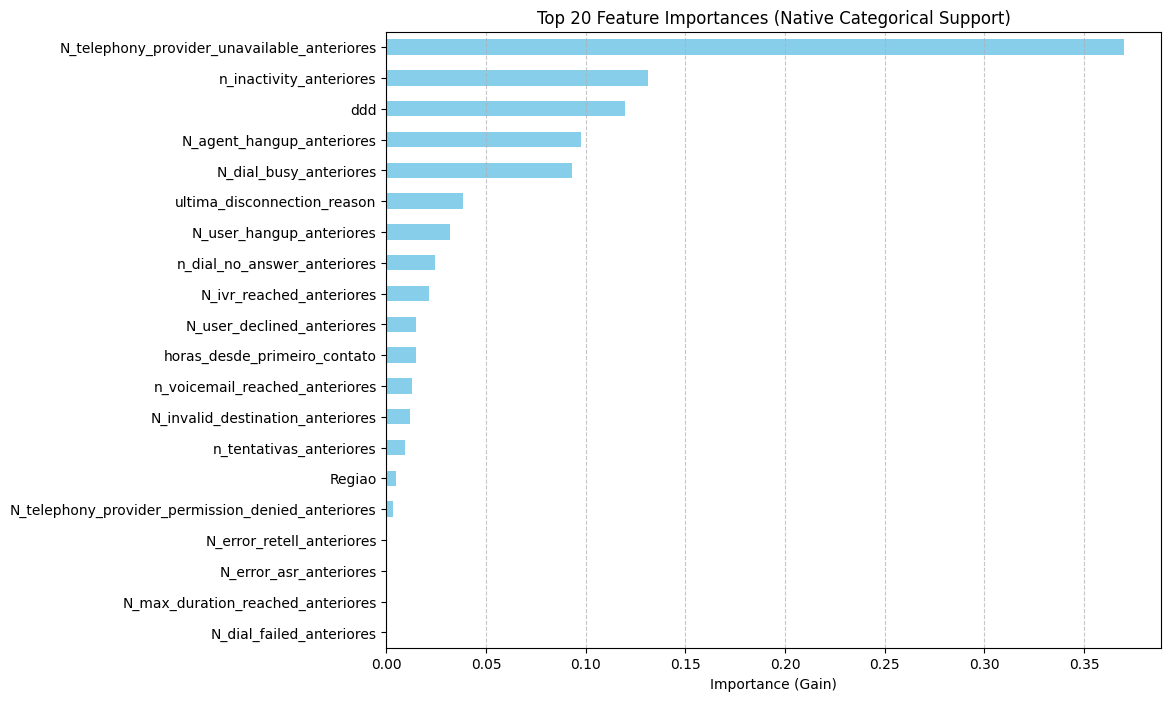

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate importance for the native categorical model
feature_names = X_train_encoded.columns.tolist()
importances = pd.Series(model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='skyblue')
plt.title('Top 20 Feature Importances (Native Categorical Support)')
plt.xlabel('Importance (Gain)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Otimização de Hiperparâmetros com GridSearchCV

Agora, para encontrar a melhor combinação de hiperparâmetros para o modelo XGBoost, utilizaremos o `GridSearchCV`. Esta técnica explora sistematicamente diversas configurações de parâmetros, avaliando o desempenho de cada uma através de validação cruzada. Nosso objetivo será maximizar o `recall`, que é crucial em cenários de dados desbalanceados onde a identificação correta da classe minoritária é prioritária.

In [15]:
from sklearn.model_selection import GridSearchCV

# Definir o espaço de parâmetros a ser explorado
param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 5, 10]
}

# Recalcular scale_pos_weight para o treinamento do GridSearchCV
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

# Inicializar o classificador XGBoost com parâmetros fixos e suporte a categorias nativo
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    enable_categorical=True,
    tree_method='hist',
    scale_pos_weight=scale_pos_weight
)

# Configurar o GridSearchCV
# Usamos 'recall' como métrica principal, pois o objetivo é otimizar a detecção da classe minoritária
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring='recall',
    cv=5, # Validação cruzada com 5 folds
    verbose=1, # Para ver o progresso
    n_jobs=-1 # Usar todos os cores disponíveis
)

# Executar a busca em grade
grid_search.fit(X_train_encoded, y_train)

print("Melhores hiperparâmetros encontrados:", grid_search.best_params_)
print("Melhor score (recall) da validação cruzada:", grid_search.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Melhores hiperparâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 300}
Melhor score (recall) da validação cruzada: 0.8688593082005441


# Metrificando Modelos

In [16]:
import pandas as pd

# 1. Extrair os resultados completos do GridSearch
resultados_completos = grid_search.cv_results_

# 2. Criar um DataFrame com os dados que nos importam
df_modelos = pd.DataFrame({
    'Ranking (Recall)': resultados_completos['rank_test_score'],
    'Recall Médio': resultados_completos['mean_test_score'],
    'Desvio Padrão': resultados_completos['std_test_score'],
    'Profundidade (max_depth)': resultados_completos['param_max_depth'],
    'Nº Árvores (n_estimators)': resultados_completos['param_n_estimators'],
    'Taxa Aprendizado (learning_rate)': resultados_completos['param_learning_rate'],
    'Filtro Exceções (min_child_weight)': resultados_completos['param_min_child_weight']
})

# 3. Ordenar do melhor para o pior modelo (focado no Recall)
df_modelos_ordenados = df_modelos.sort_values(by='Ranking (Recall)')

# 4. Exibir o Top 10 e o Pior modelo para vermos a evolução
print("=== TOP 5 MELHORES CONFIGURAÇÕES (Otimizadas para Recall) ===")
print(df_modelos_ordenados.head(5).to_string(index=False))

print("\n=== A PIOR CONFIGURAÇÃO (O que EVITAR) ===")
print(df_modelos_ordenados.tail(1).to_string(index=False))

=== TOP 5 MELHORES CONFIGURAÇÕES (Otimizadas para Recall) ===
 Ranking (Recall)  Recall Médio  Desvio Padrão  Profundidade (max_depth)  Nº Árvores (n_estimators)  Taxa Aprendizado (learning_rate)  Filtro Exceções (min_child_weight)
                1      0.868859       0.017057                         3                        300                               0.1                                  10
                2      0.865637       0.019236                         3                        300                               0.1                                   5
                3      0.864837       0.014148                         3                        300                               0.1                                   1
                4      0.864830       0.010536                         3                        200                               0.1                                  10
                5      0.862421       0.015647                         5                

In [17]:
print("=== TOP 10 MELHORES CONFIGURAÇÕES (Otimizadas para Recall) ===")
display(df_modelos_ordenados.head(10))

=== TOP 10 MELHORES CONFIGURAÇÕES (Otimizadas para Recall) ===


,Ranking (Recall),Recall Médio,Desvio Padrão,Profundidade (max_depth),Nº Árvores (n_estimators),Taxa Aprendizado (learning_rate),Filtro Exceções (min_child_weight)
62,1,0.868859,0.017057,3,300,0.10,10
59,2,0.865637,0.019236,3,300,0.10,5
56,3,0.864837,0.014148,3,300,0.10,1
61,4,0.864830,0.010536,3,200,0.10,10
69,5,0.862421,0.015647,5,100,0.10,10
44,6,0.861627,0.017907,5,300,0.05,10
66,7,0.861621,0.016831,5,100,0.10,5
55,8,0.861614,0.016305,3,200,0.10,1
70,9,0.860814,0.014584,5,200,0.10,10
71,10,0.860008,0.014104,5,300,0.10,10


Temos 1 modelos empatados com Recall de 0.8689


,params,mean_test_score,std_test_score
62,"{'learning_rate': 0.1, 'max_depth': 3, 'min_ch...",0.868859,0.017057


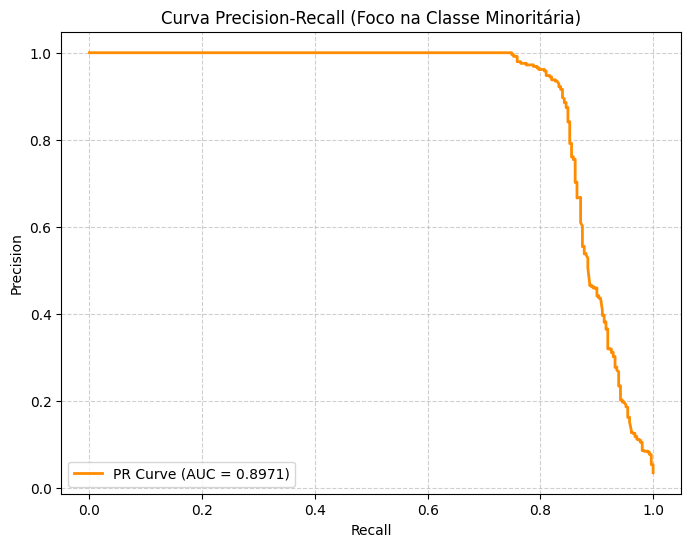


Relatório de Classificação Final (Conjunto de Teste):
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      8825
           1       0.56      0.87      0.68       311

    accuracy                           0.97      9136
   macro avg       0.78      0.93      0.83      9136
weighted avg       0.98      0.97      0.98      9136



In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, classification_report

# 1. Comparando Precisão vs Recall para os modelos do Grid
# O GridSearchCV por padrão foca apenas na métrica de scoring definida,
# mas podemos extrair outras métricas se tivéssemos definido refit='recall'
df_detalhado = pd.DataFrame(grid_search.cv_results_)

# Filtrando apenas os que tiveram o recall máximo
melhor_recall = df_detalhado['mean_test_score'].max()
top_models = df_detalhado[df_detalhado['mean_test_score'] == melhor_recall].copy()

print(f"Temos {len(top_models)} modelos empatados com Recall de {melhor_recall:.4f}")
display(top_models[['params', 'mean_test_score', 'std_test_score']].head())

# 2. Avaliando a curva de Precision-Recall do melhor estimador no conjunto de teste
best_model = grid_search.best_estimator_
y_probs = best_model.predict_proba(X_test_encoded)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})', color='darkorange', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall (Foco na Classe Minoritária)')
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Relatório de Classificação Completo
print("\nRelatório de Classificação Final (Conjunto de Teste):")
print(classification_report(y_test, best_model.predict(X_test_encoded)))

In [19]:
import pandas as pd

print("🔔 Simulando novo lead com as features atuais do modelo...")

# 1. Payload ajustado para as colunas presentes no X_train (20 colunas)
# Removido: agent_id, hora_contato, dia_semana, Is_horario_comercial, is_fim_de_semana, duracao_max_anterior, duracao_total_anterior
novo_lead_json = {
    'ddd': '11',
    'Regiao': 'SP',
    'n_tentativas_anteriores': 1,
    'horas_desde_primeiro_contato': 2.5,
    'n_voicemail_reached_anteriores': 0,
    'n_dial_no_answer_anteriores': 1,
    'n_inactivity_anteriores': 0,
    'N_invalid_destination_anteriores': 0,
    'N_user_hangup_anteriores': 0,
    'N_user_declined_anteriores': 0,
    'N_telephony_provider_permission_denied_anteriores': 0,
    'N_dial_busy_anteriores': 0,
    'N_telephony_provider_unavailable_anteriores': 0,
    'N_agent_hangup_anteriores': 0,
    'N_error_asr_anteriores': 0,
    'N_error_retell_anteriores': 0,
    'N_dial_failed_anteriores': 0,
    'N_max_duration_reached_anteriores': 0,
    'N_ivr_reached_anteriores': 0,
    'ultima_disconnection_reason': 'dial_no_answer'
}

# 2. Converte para DataFrame
df_novo_lead = pd.DataFrame([novo_lead_json])

# 3. MÓDULO DE ETL (Garantindo tipos categóricos conforme o treino)
colunas_categoricas = ['ddd', 'Regiao', 'ultima_disconnection_reason']
for col in colunas_categoricas:
    df_novo_lead[col] = df_novo_lead[col].astype(str).astype('category')

# 4. INFERÊNCIA
# Usando o best_model (XGBoost com enable_categorical=True)
probabilidade_sucesso = best_model.predict_proba(df_novo_lead)[0][1]

print(f"\n📊 Diagnóstico da IA:")
print(f"Probabilidade de Conversão (>1 min): {probabilidade_sucesso * 100:.2f}%")

# Threshold decidido
THRESHOLD = 0.20

if probabilidade_sucesso >= THRESHOLD:
    print(f"✅ DECISÃO: INICIAR CHAMADA.")
else:
    print(f"❌ DECISÃO: NÃO LIGAR AGORA.")

🔔 Simulando novo lead com as features atuais do modelo...

📊 Diagnóstico da IA:
Probabilidade de Conversão (>1 min): 14.26%
❌ DECISÃO: NÃO LIGAR AGORA.


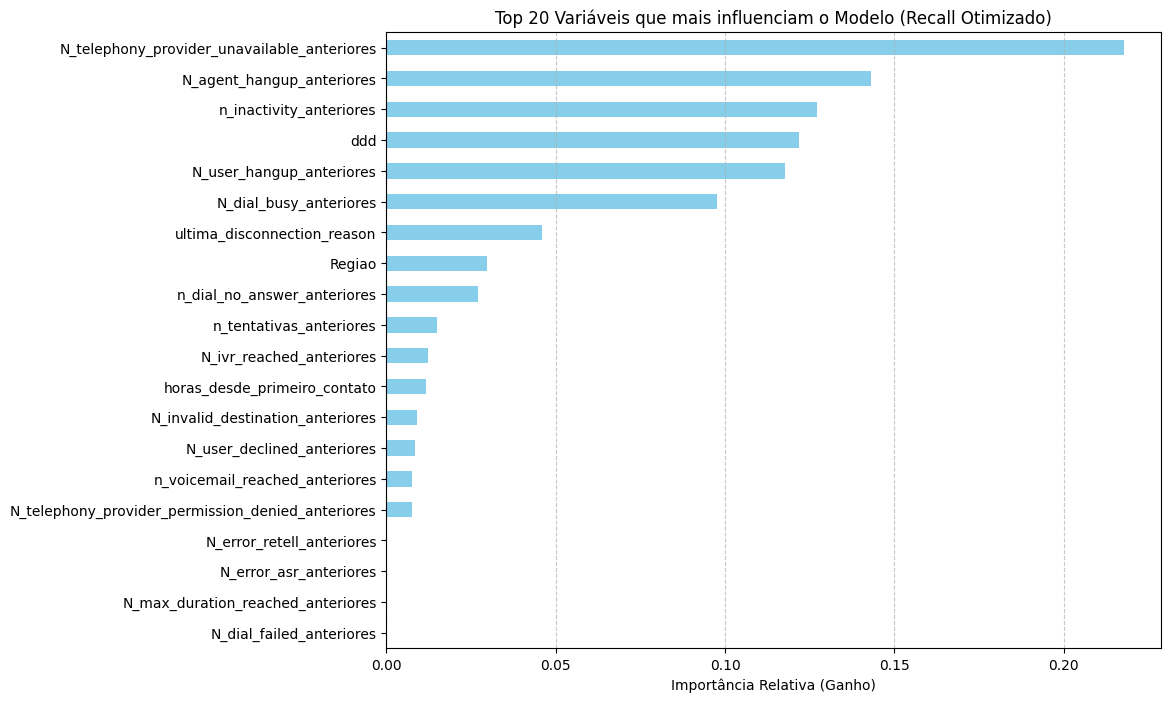

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extrair importâncias do melhor modelo treinado
feature_names = X_train_encoded.columns.tolist()
importances = pd.Series(best_model.feature_importances_, index=feature_names)

# 2. Ordenar e selecionar as 20 mais importantes
importances = importances.sort_values(ascending=False).head(20)

# 3. Plotar
plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='skyblue')
plt.title('Top 20 Variáveis que mais influenciam o Modelo (Recall Otimizado)')
plt.xlabel('Importância Relativa (Ganho)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [21]:
from sklearn.metrics import recall_score, precision_score, roc_auc_score

y_pred_best = best_model.predict(X_test_encoded)
y_probs_best = best_model.predict_proba(X_test_encoded)[:, 1]

recall = recall_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
roc_auc = roc_auc_score(y_test, y_probs_best)

print(f'Resultados do Modelo Otimizado:')
print(f'Recall: {recall:.4f}')
print(f'Precisão: {precision:.4f}')
print(f'ROC AUC Score: {roc_auc:.4f}')

Resultados do Modelo Otimizado:
Recall: 0.8746
Precisão: 0.5574
ROC AUC Score: 0.9795


In [22]:
from sklearn.metrics import confusion_matrix

# Gerar a matriz de confusão para o conjunto de teste usando o melhor modelo
cm_best = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()

print(f"=== Matriz de Confusão (Modelo Otimizado) ===")
print(f"Verdadeiros Negativos (0): {tn}")
print(f"Falsos Positivos (Erro Tipo I): {fp}")
print(f"Falsos Negativos (Erro Tipo II): {fn}")
print(f"Verdadeiros Positivos (1): {tp}")

print("\nRepresentação em Array:")
print(cm_best)

=== Matriz de Confusão (Modelo Otimizado) ===
Verdadeiros Negativos (0): 8609
Falsos Positivos (Erro Tipo I): 216
Falsos Negativos (Erro Tipo II): 39
Verdadeiros Positivos (1): 272

Representação em Array:
[[8609  216]
 [  39  272]]


--- Distribuição de Variáveis Numéricas ---


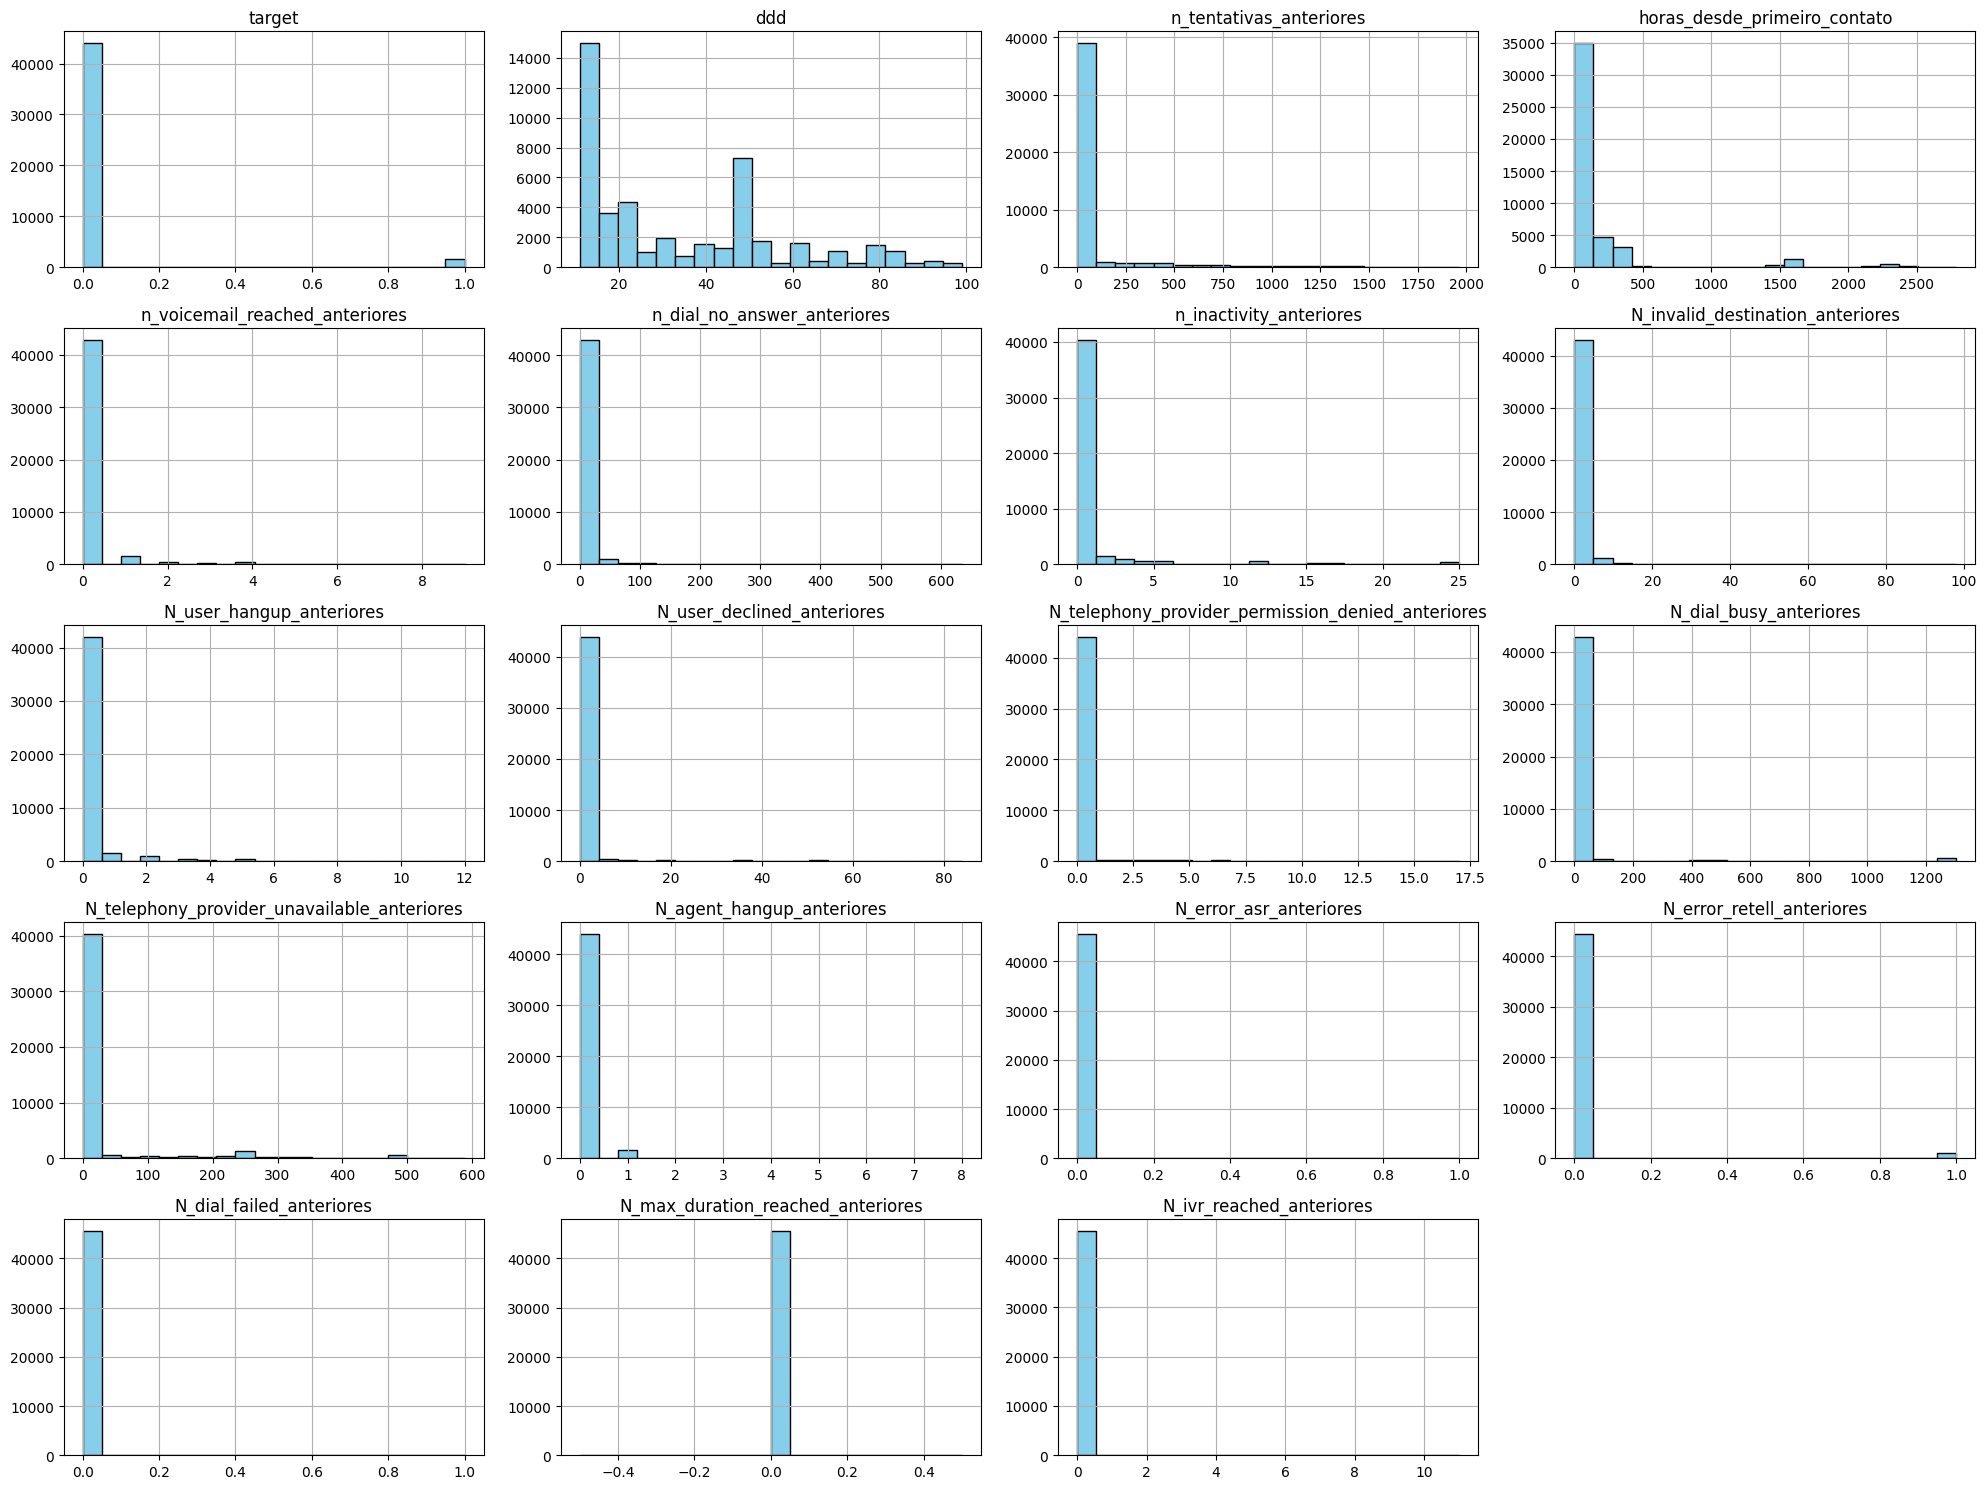


--- Distribuição de Variáveis Categóricas Principais ---


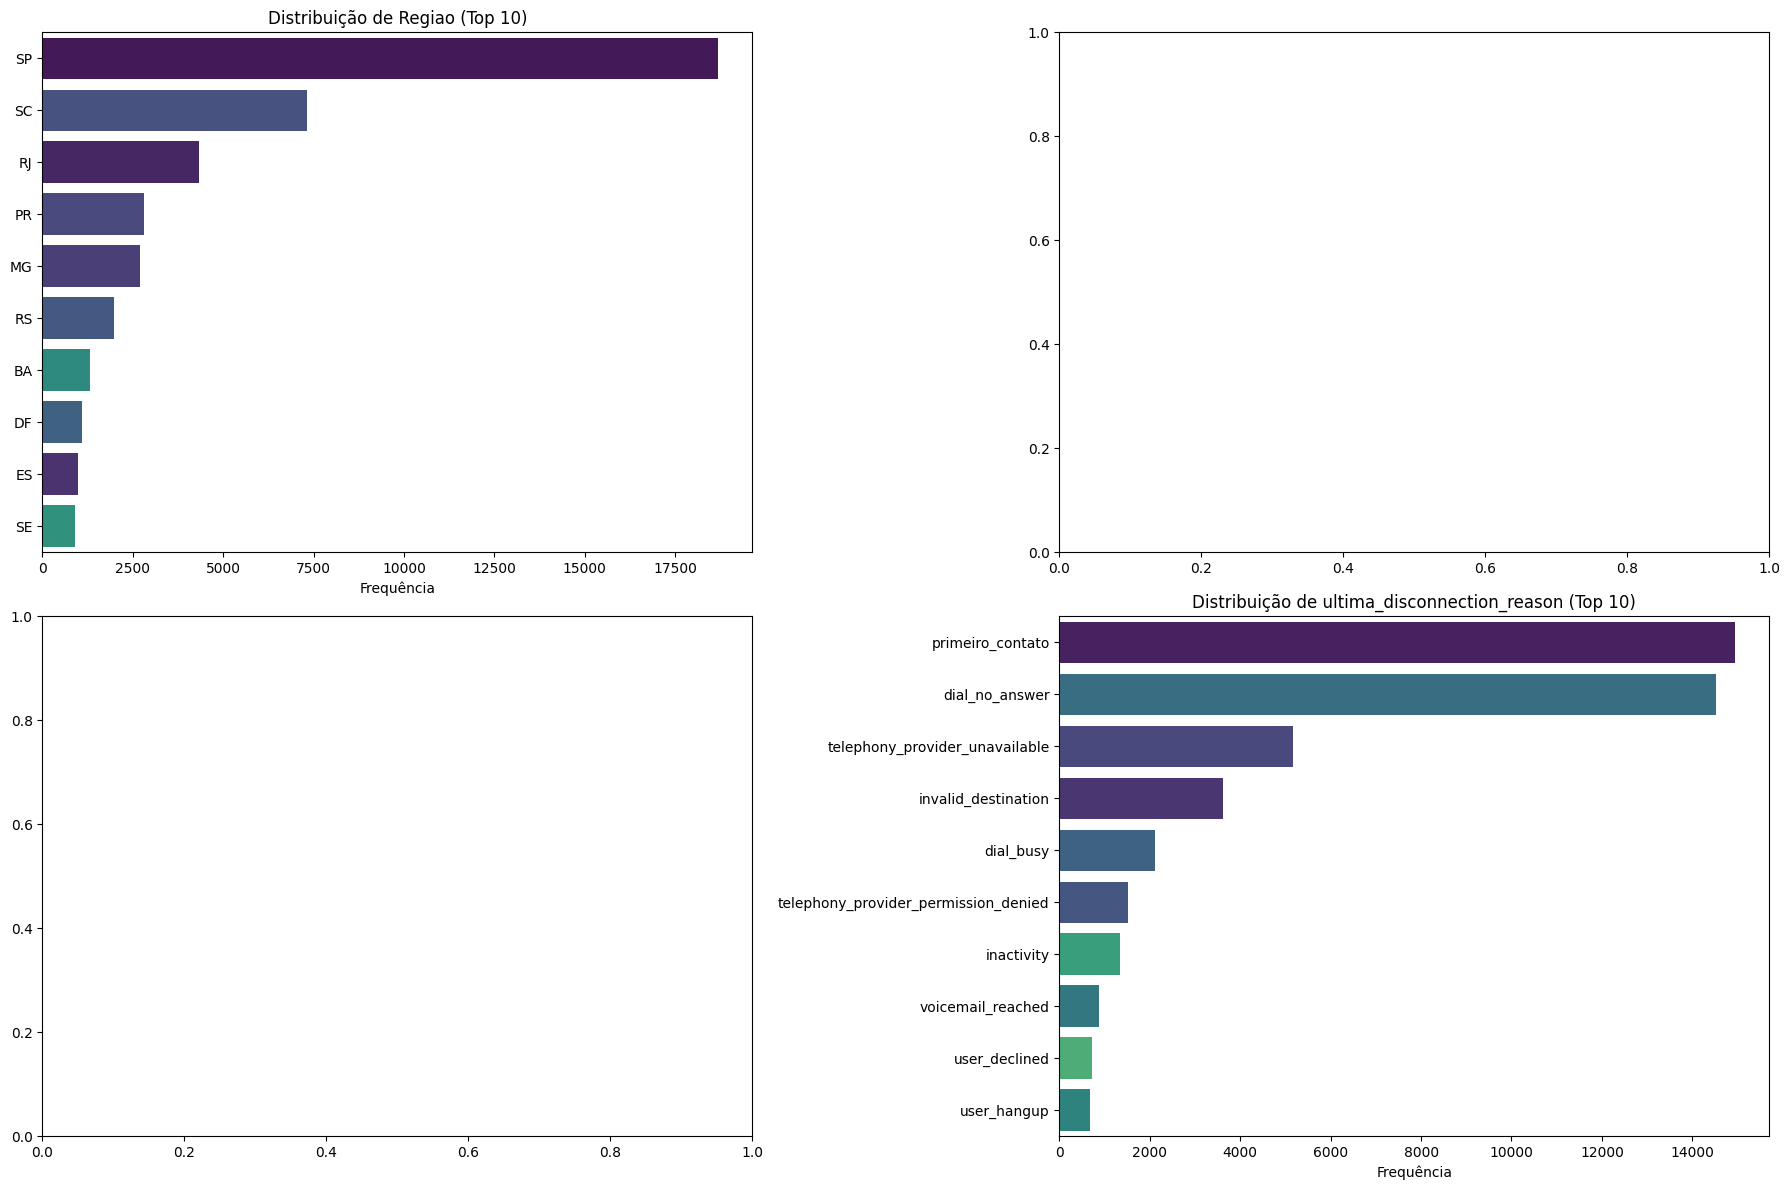

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando colunas numéricas e categóricas para visualização
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = ['Regiao', 'hora_contato', 'dia_semana', 'ultima_disconnection_reason']

# 1. Distribuição de Variáveis Numéricas
print("--- Distribuição de Variáveis Numéricas ---")
df[numerical_cols].hist(bins=20, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

# 2. Distribuição de Variáveis Categóricas (Top Categorias)
print("\n--- Distribuição de Variáveis Categóricas Principais ---")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        order = df[col].value_counts().index[:10] # Top 10 para não poluir o gráfico
        sns.countplot(data=df, y=col, ax=axes[i], order=order, palette='viridis', hue=col, legend=False)
        axes[i].set_title(f'Distribuição de {col} (Top 10)')
        axes[i].set_xlabel('Frequência')
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

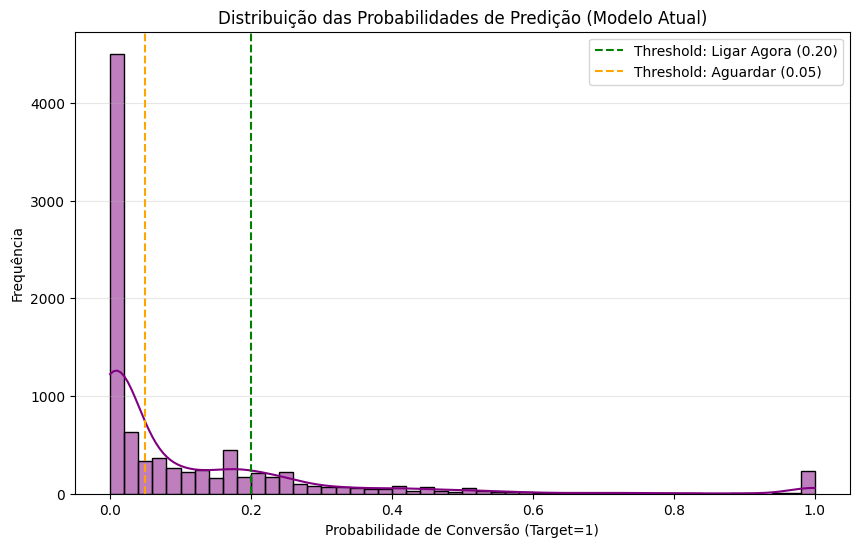

Estatísticas das Probabilidades:
count    9.136000e+03
mean     1.178223e-01
std      2.019553e-01
min      4.768135e-07
25%      1.593982e-03
50%      2.184928e-02
75%      1.763692e-01
max      9.999787e-01
dtype: float64


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ajustado para usar as variáveis existentes no kernel: best_model e X_test_encoded
y_probs_test = best_model.predict_proba(X_test_encoded)[:, 1]

# Criando o gráfico de distribuição
plt.figure(figsize=(10, 6))
sns.histplot(y_probs_test, bins=50, kde=True, color='purple')

# Atualizando as linhas para os thresholds de decisão atuais (0.20 e 0.05)
plt.axvline(x=0.20, color='green', linestyle='--', label='Threshold: Ligar Agora (0.20)')
plt.axvline(x=0.05, color='orange', linestyle='--', label='Threshold: Aguardar (0.05)')

plt.title('Distribuição das Probabilidades de Predição (Modelo Atual)')
plt.xlabel('Probabilidade de Conversão (Target=1)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Estatísticas descritivas das probabilidades
print("Estatísticas das Probabilidades:")
print(pd.Series(y_probs_test).describe())

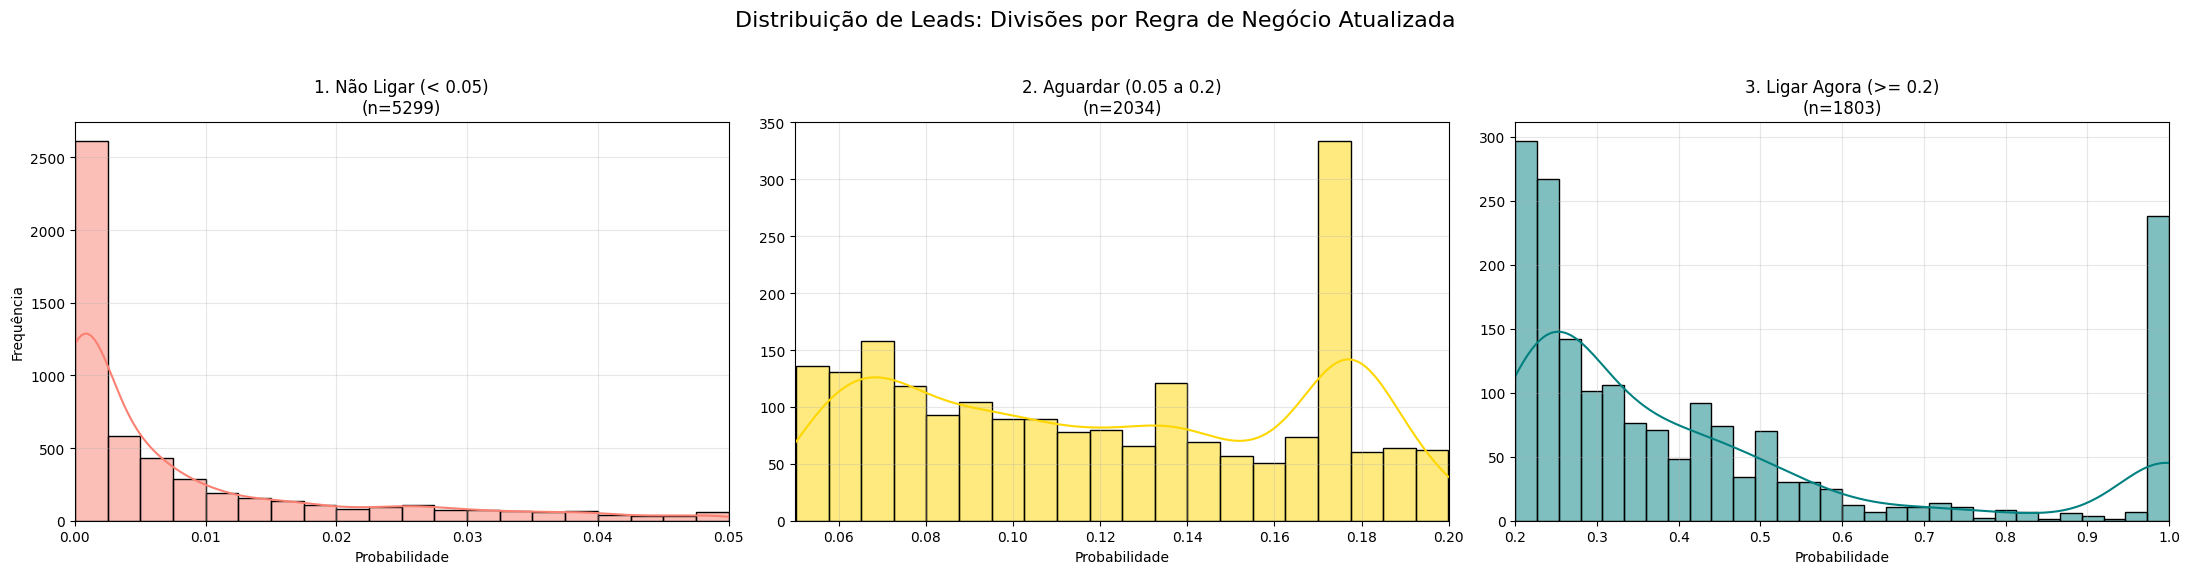

Total de leads no teste: 9136
1. Leads NÃO LIGAR (< 0.05): 5299 (58.0%)
2. Leads AGUARDAR: 2034 (22.3%)
3. Leads LIGAR AGORA: 1803 (19.7%) 


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Thresholds de Negócio Atualizados (Conforme última definição)
THRESHOLD_DISCARD = 0.05
THRESHOLD_CALL_NOW = 0.20

# Probabilidades do modelo atual
y_probs_test = best_model.predict_proba(X_test_encoded)[:, 1]

# Agrupamento sem sobreposição
# Grupo 1: < 0.05
probs_discard = y_probs_test[y_probs_test < THRESHOLD_DISCARD]
# Grupo 2: 0.05 <= p < 0.20
probs_reschedule = y_probs_test[(y_probs_test >= THRESHOLD_DISCARD) & (y_probs_test < THRESHOLD_CALL_NOW)]
# Grupo 3: >= 0.20
probs_call_now = y_probs_test[y_probs_test >= THRESHOLD_CALL_NOW]

# Criando a figura
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# Gráfico 1: Zona de Descarte / Aguardar
sns.histplot(probs_discard, bins=20, kde=True, color='salmon', ax=ax1)
ax1.set_xlim(0, THRESHOLD_DISCARD)
ax1.set_title(f'1. Não Ligar (< {THRESHOLD_DISCARD})\n(n={len(probs_discard)})')
ax1.set_xlabel('Probabilidade')
ax1.set_ylabel('Frequência')
ax1.grid(alpha=0.3)

# Gráfico 2: Zona de Outro Horário
sns.histplot(probs_reschedule, bins=20, kde=True, color='gold', ax=ax2)
ax2.set_xlim(THRESHOLD_DISCARD, THRESHOLD_CALL_NOW)
ax2.set_title(f'2. Aguardar ({THRESHOLD_DISCARD} a {THRESHOLD_CALL_NOW})\n(n={len(probs_reschedule)})')
ax2.set_xlabel('Probabilidade')
ax2.set_ylabel('')
ax2.grid(alpha=0.3)

# Gráfico 3: Zona de Ligar Agora
sns.histplot(probs_call_now, bins=30, kde=True, color='teal', ax=ax3)
ax3.set_xlim(THRESHOLD_CALL_NOW, 1.0)
ax3.set_title(f'3. Ligar Agora (>= {THRESHOLD_CALL_NOW})\n(n={len(probs_call_now)})')
ax3.set_xlabel('Probabilidade')
ax3.set_ylabel('')
ax3.grid(alpha=0.3)

plt.suptitle('Distribuição de Leads: Divisões por Regra de Negócio Atualizada', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Sumário Executivo
print(f"Total de leads no teste: {len(y_probs_test)}")
print(f"1. Leads NÃO LIGAR (< {THRESHOLD_DISCARD}): {len(probs_discard)} ({len(probs_discard)/len(y_probs_test)*100:.1f}%)")
print(f"2. Leads AGUARDAR: {len(probs_reschedule)} ({len(probs_reschedule)/len(y_probs_test)*100:.1f}%)")
print(f"3. Leads LIGAR AGORA: {len(probs_call_now)} ({len(probs_call_now)/len(y_probs_test)*100:.1f}%) ")

Como as features de tempo se mostram pouco relevantes para a classificação. Talvez tenhamos que ter dois modelos: um para decidir se continua ou não tentativas com o lead e outro para decidir melhor momento


/tmp/ipykernel_1877/338640839.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1877/338640839.py:37: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


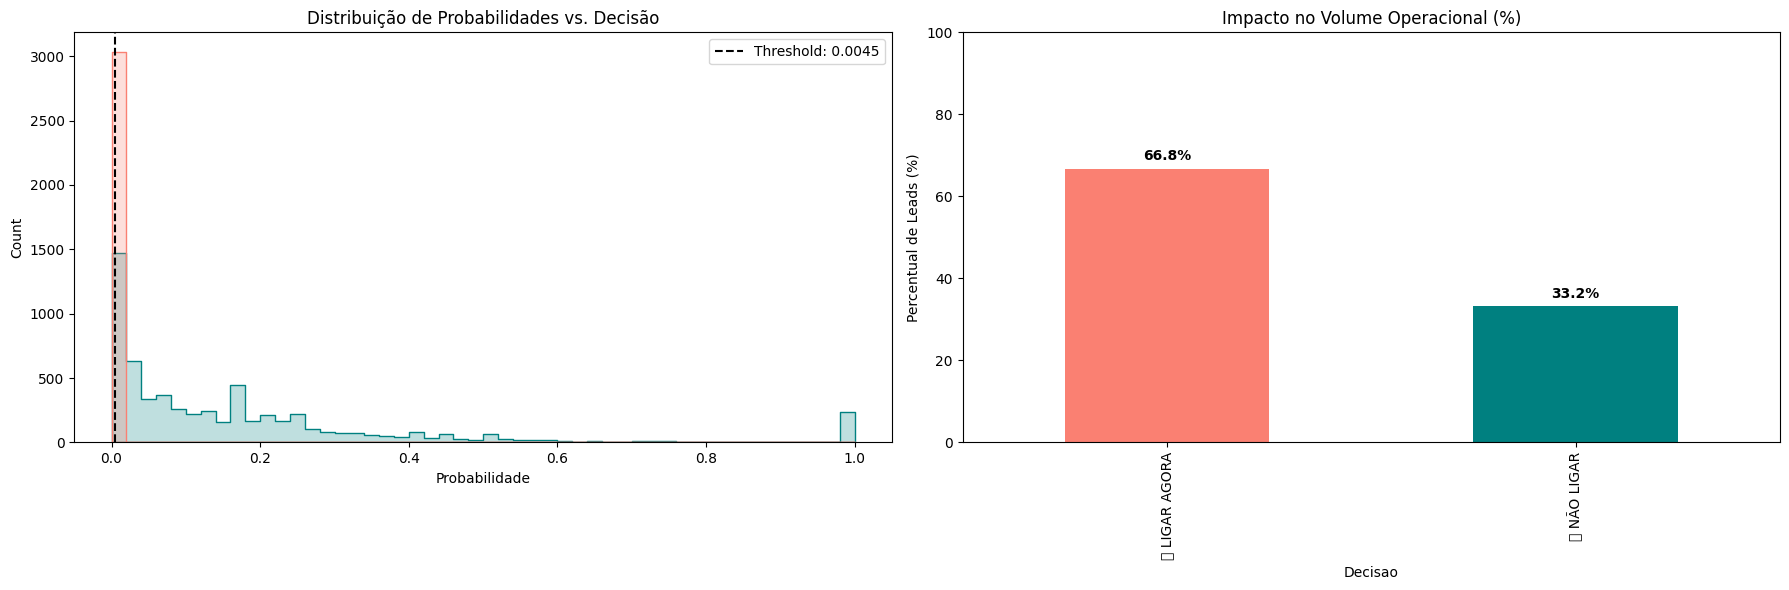

--- RESUMO COM THRESHOLD DE 0.0045 ---
Total de Leads: 9136
Leads para LIGAR: 6102 (66.8%)
Leads filtrados (NÃO LIGAR): 3034 (33.2%)


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- AJUSTE O THRESHOLD AQUI ---
THRESHOLD = 0.0045
# ------------------------------

# 1. Obter probabilidades do melhor modelo
y_probs = best_model.predict_proba(X_test_encoded)[:, 1]

# 2. Classificação Binária
decisoes = np.where(y_probs >= THRESHOLD, '✅ LIGAR AGORA', '❌ NÃO LIGAR')
df_results = pd.DataFrame({'Probabilidade': y_probs, 'Decisao': decisoes})

# 3. Visualização
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico A: Distribuição de Probabilidades com o Threshold
sns.histplot(data=df_results, x='Probabilidade', hue='Decisao',
             element='step', bins=50, palette={'✅ LIGAR AGORA': 'teal', '❌ NÃO LIGAR': 'salmon'}, ax=ax[0])
ax[0].axvline(THRESHOLD, color='black', linestyle='--', label=f'Threshold: {THRESHOLD}')
ax[0].set_title('Distribuição de Probabilidades vs. Decisão')
ax[0].legend()

# Gráfico B: Volume Operacional
counts = df_results['Decisao'].value_counts(normalize=True) * 100
counts.plot(kind='bar', color=['salmon', 'teal'], ax=ax[1])
ax[1].set_title('Impacto no Volume Operacional (%)')
ax[1].set_ylabel('Percentual de Leads (%)')
ax[1].set_ylim(0, 100)

for i, v in enumerate(counts):
    ax[1].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Sumário
total = len(df_results)
ligar = len(df_results[df_results['Decisao'] == '✅ LIGAR AGORA'])
print(f"--- RESUMO COM THRESHOLD DE {THRESHOLD} ---")
print(f"Total de Leads: {total}")
print(f"Leads para LIGAR: {ligar} ({ligar/total*100:.1f}%)")
print(f"Leads filtrados (NÃO LIGAR): {total-ligar} ({(total-ligar)/total*100:.1f}%)")

In [27]:
df_results['Real'] = y_test

# Filtrar leads classificados como 'NÃO LIGAR'
leads_nao_ligar = df_results[df_results['Decisao'] == '❌ NÃO LIGAR']

# Contar falsos negativos dentro deste grupo
# Falso Negativo: previsto como '0' (não ligar) mas o real é '1' (deveria ligar)
false_negatives = leads_nao_ligar[leads_nao_ligar['Real'] == 1]

total_falsos_negativos = len(false_negatives)
total_leads_nao_ligar = len(leads_nao_ligar)

# Calcular porcentagem
percentage_falsos_negativos = (total_falsos_negativos / total_leads_nao_ligar) * 100 if total_leads_nao_ligar > 0 else 0

print(f"Total de leads filtrados (NÃO LIGAR): {total_leads_nao_ligar}")
print(f"Falsos Negativos entre os leads filtrados (NÃO LIGAR): {total_falsos_negativos}")
print(f"Porcentagem de Falsos Negativos entre os leads filtrados (NÃO LIGAR): {percentage_falsos_negativos:.2f}%")

Total de leads filtrados (NÃO LIGAR): 3034
Falsos Negativos entre os leads filtrados (NÃO LIGAR): 1
Porcentagem de Falsos Negativos entre os leads filtrados (NÃO LIGAR): 0.03%


In [28]:
import pickle
from google.colab import files

# Nome do arquivo de destino
model_filename = 'xgboost_LS_model.pkl'

# Salvar o modelo usando pickle
with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)

print(f'Modelo salvo como {model_filename}. Iniciando download...')

# Trigger do download no navegador
files.download(model_filename)

Modelo salvo como xgboost_LS_model.pkl. Iniciando download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# Listando os valores únicos possíveis para a coluna Regiao
print("Inputs possíveis para a coluna 'Regiao':")
print(df['Regiao'].unique())

# Caso queira ver a contagem de cada um:
# print(df['Regiao'].value_counts())

Inputs possíveis para a coluna 'Regiao':
['SP' 'RJ' 'ES' 'MG' 'PR' 'SC' 'RS' 'DF' 'GO' 'MT' 'MS' 'AC' 'RO' 'BA'
 'SE' 'PE' 'AL' 'PB' 'RN' 'CE' 'PI' 'PA' 'AM' 'RR' 'MA']
